In [1]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

print("\nMissing values:\n")
print(sentiment.isnull().sum())
print(trades.isnull().sum())

print("\nDuplicates:")
print("Sentiment:", sentiment.duplicated().sum())
print("Trades:", trades.duplicated().sum())

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)

Missing values:

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates:
Sentiment: 0
Trades: 0


In [2]:
# Convert dates
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

# Extract date
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [3]:
print(trades['date'].min(), trades['date'].max())
print(sentiment['date'].min(), sentiment['date'].max())

2023-05-01 2025-05-01
2018-02-01 2025-05-02


In [4]:
sentiment_sample = sentiment.sample(len(trades), replace=True).reset_index(drop=True)

merged = trades.copy()
merged['classification'] = sentiment_sample['classification']
merged['sentiment_value'] = sentiment_sample['value']

In [5]:
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

In [6]:
merged['win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('Account')['win'].mean().reset_index()

In [7]:
trades_per_day = merged.groupby('date').size().reset_index(name='num_trades')

In [8]:
long_short = merged.groupby(['date', 'Direction']).size().unstack(fill_value=0)

In [9]:
# PnL
merged.groupby('classification')['Closed PnL'].mean()

# Win rate
merged.groupby('classification')['win'].mean()

# Loss (drawdown proxy)
merged['loss'] = merged['Closed PnL'] < 0
merged.groupby('classification')['loss'].mean()

classification
Extreme Fear     0.084226
Extreme Greed    0.082372
Fear             0.082620
Greed            0.082882
Neutral          0.083115
Name: loss, dtype: float64

In [12]:
merged['risk_level'] = merged['Size USD'].apply(lambda x: 'High' if x > 1000 else 'Low')

In [15]:
trade_counts = merged['Account'].value_counts()
frequent = trade_counts[trade_counts > 50].index

merged['trader_type'] = merged['Account'].apply(lambda x: 'Frequent' if x in frequent else 'Infrequent')

In [16]:
total_pnl = merged.groupby('Account')['Closed PnL'].sum()
winners = total_pnl[total_pnl > 0].index

merged['performance'] = merged['Account'].apply(lambda x: 'Winner' if x in winners else 'Loser')

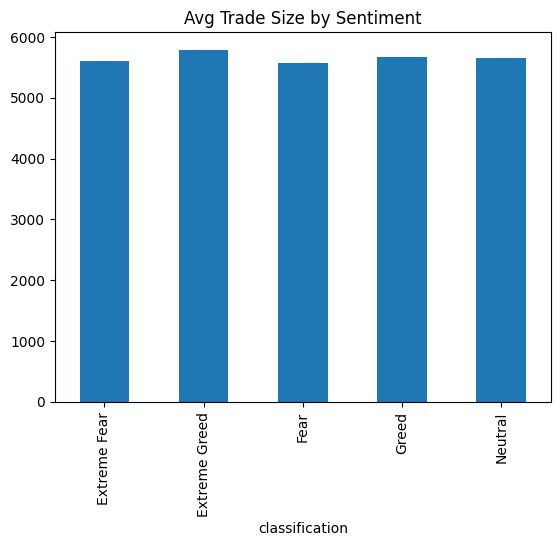

In [30]:
merged.groupby('classification')['Size USD'].mean().plot(kind='bar', title='Avg Trade Size by Sentiment')
plt.savefig("outputs/trade_size_plot.png")

In [21]:
# Trade size
merged.groupby('classification')['Size USD'].mean()

# Trade frequency
merged.groupby('classification').size()

# Long/Short bias
merged.groupby(['classification', 'Direction']).size().unstack()

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,1.0,3072.0,9478.0,6933.0,NaN,12.0,9589.0,7582.0,3803.0,NaN,19.0,21.0
Extreme Greed,NaN,1997.0,5900.0,4421.0,1.0,7.0,6117.0,5057.0,2409.0,NaN,8.0,14.0
Fear,3.0,5083.0,14385.0,10619.0,NaN,20.0,14813.0,11641.0,5894.0,NaN,18.0,51.0
Greed,2.0,4089.0,11487.0,8559.0,NaN,13.0,11802.0,9482.0,4787.0,1.0,12.0,30.0
Neutral,2.0,2475.0,7428.0,5481.0,NaN,5.0,7574.0,5979.0,3009.0,NaN,13.0,26.0


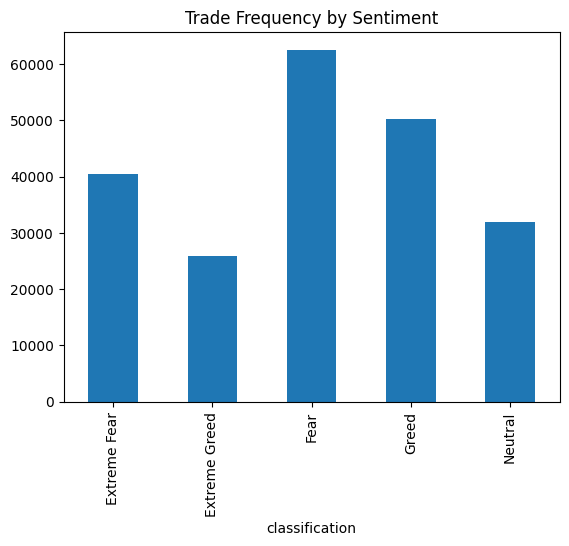

In [29]:
merged.groupby('classification').size().plot(kind='bar', title='Trade Frequency by Sentiment')
plt.savefig("outputs/trade_freq_plot.png")

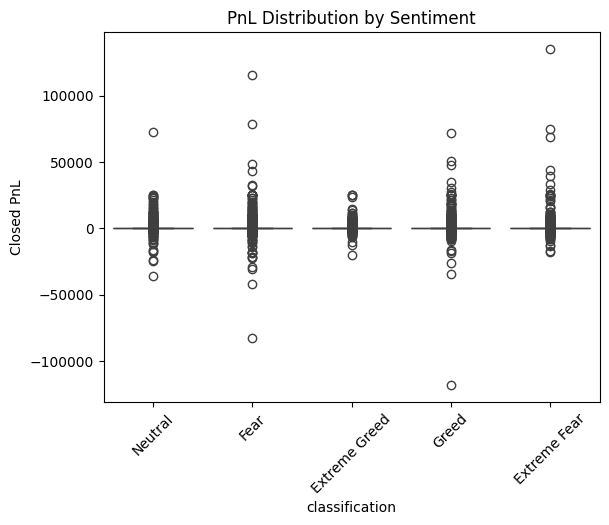

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution by Sentiment")
plt.xticks(rotation=45)
plt.savefig("outputs/pnl_plot.png")
plt.show()
